# Worksheet 3 - Modelling the Neuron
## 6CS012 - Artificial Intelligence and Machine Learning
### Name: sijan kunwar


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Task 1: MCP Neurons
Implement MCP neuron for AND and OR using threshold logic.


In [4]:
def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)
    state_neuron = []

    for i in range(len(X1)):
        s = X1[i] + X2[i]
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


In [5]:
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result_and = MCP_Neurons_AND(X1, X2, T)
print("AND Output:", result_and)


AND Output: [0, 0, 0, 1]


In [6]:
def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)
    state_neuron = []

    for i in range(len(X1)):
        s = X1[i] + X2[i]
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


In [7]:
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1

result_or = MCP_Neurons_OR(X1, X2, T)
print("OR Output:", result_or)


OR Output: [0, 1, 1, 1]


## Task 1 Answers

### Question 1: Limitations of MCP Neuron
- MCP neuron uses fixed threshold values.
- It does not learn from data.
- It can solve only simple linearly separable problems.
- It cannot solve XOR with a single neuron.
- It is too simplified compared to real biological neurons.

### Question 2: Can XOR be solved using MCP neuron?
A single MCP neuron cannot solve XOR because XOR is not linearly separable.
We can write XOR manually using if-else rules, but not using one MCP neuron with one threshold.


## Task 2: Perceptron Algorithm for 0 vs 1 Classification
Upload `mnist_0_and_1.csv` to Colab before running the next cells.


In [10]:
df_0_1 = pd.read_csv("/content/mnist_0_and_1.csv")

print("Columns in df_0_1:", df_0_1.columns)

X = df_0_1.drop(columns=["Unnamed: 0"]).values
y = df_0_1["Unnamed: 0"].values

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Columns in df_0_1: Index(['Unnamed: 0', '92', '251', '254', '136', '35', '0', '0.1', '0.2', '0.3',
       ...
       '0.123', '0.124', '0.125', '0.126', '0.127', '0.128', '0.129', '0.130',
       '0.131', '0.132'],
      dtype='object', length=156)
Feature matrix shape: (467, 155)
Label vector shape: (467,)


## Task 2 Answers: Dataset

### Question 1: What does the shape of X represent?
It represents the number of images and the number of features (pixels) in each image.

### Question 2: What does the shape of y represent?
It represents the number of labels, one for each image.


Error: Not enough images to display.


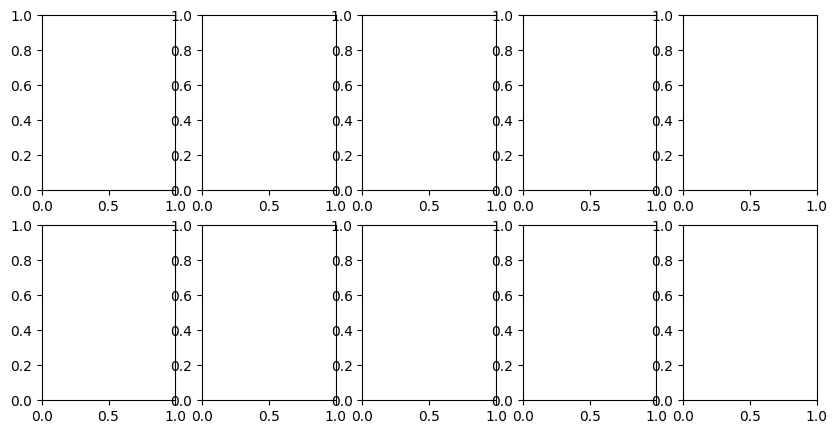

In [11]:
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images to display.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()


In [13]:
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100


## Task 2 Answers: Initialization

### Question 3: What does the weights array represent?
It stores one weight for each pixel feature.

### Question 4: Why initialize weights to zero?
It gives a simple starting point and allows the perceptron to learn from errors during training.


In [14]:
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all


In [17]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0

            error = y[i] - y_pred

            if error != 0:
                weights = weights + learning_rate * error * X[i]
                bias = bias + learning_rate * error
            else:
                correct += 1

        accuracy = correct / len(X)

        if accuracy == 1.0:
            print(f"Training converged at epoch {epoch+1}")
            break

    return weights, bias, accuracy


## Task 2 Answers: Training

### Question 5: What is the purpose of `output = np.dot(X[i], weights) + bias`?
It calculates the weighted sum of the input features and bias to make a prediction.

### Question 6: What happens when the prediction is wrong?
The weights and bias are updated using the perceptron learning rule.

### Question 7: Why is final accuracy important?
It shows how well the model classifies the dataset.


In [18]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)
print("The Final Accuracy is:", accuracy)


The Final Accuracy is: 0.0021413276231263384


In [19]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")


Final Accuracy: 0.0021


In [23]:
misclassified_idx = np.where(y_pred != y)[0]

print("Number of misclassified samples:", len(misclassified_idx))
print("Feature size per sample:", X.shape[1])

side = int(np.sqrt(X.shape[1]))
if side * side == X.shape[1] and len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(side, side), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("Misclassified images cannot be displayed because 155 cannot be reshaped into a square image.")





Number of misclassified samples: 466
Feature size per sample: 155
Misclassified images cannot be displayed because 155 cannot be reshaped into a square image.


## Task 2 Answers: Misclassification

### Question 8: What does misclassified_idx store?
It stores the indices of samples where the predicted label is different from the true label.

### Question 9: What does “All images were correctly classified!” mean?
It means the perceptron predicted every sample correctly.

### Note about visualization
The worksheet example assumes 784-pixel MNIST images, but the provided CSV has 155 features per sample.
So direct image visualization using reshape(28, 28) is not possible for this file.


## Task 3: Perceptron Algorithm for 3 vs 5 Classification
Upload `mnist_3_and_5.csv` before running the next cells.


In [25]:
df_3_5 = pd.read_csv("/content/mnist_3_and_5.csv")

X35 = df_3_5.drop(columns=["label"]).values
y35_original = df_3_5["label"].values

print("Feature matrix shape:", X35.shape)
print("Label vector shape:", y35_original.shape)
print("One row size:", X35.shape[1])



Feature matrix shape: (2741, 784)
Label vector shape: (2741,)
One row size: 784


Feature size per sample: 784


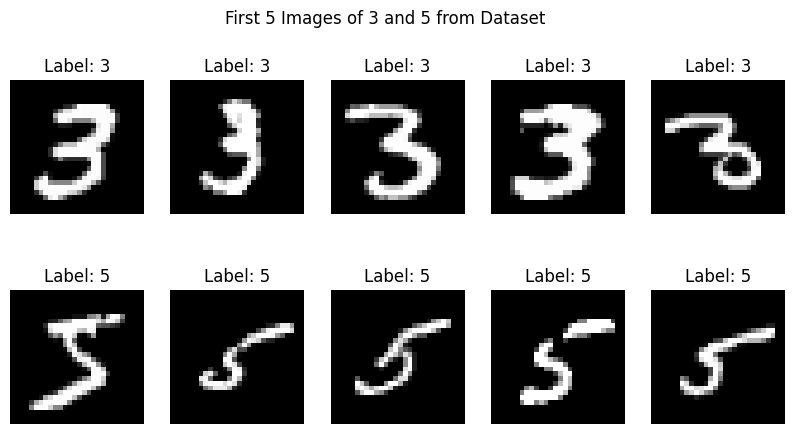

In [26]:
side35 = int(np.sqrt(X35.shape[1]))

print("Feature size per sample:", X35.shape[1])

if side35 * side35 == X35.shape[1]:
    images_3 = X35[y35_original == 3]
    images_5 = X35[y35_original == 5]

    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    if len(images_3) < 5 or len(images_5) < 5:
        print("Error: Not enough images to display.")
    else:
        for i in range(5):
            axes[0, i].imshow(images_3[i].reshape(side35, side35), cmap="gray")
            axes[0, i].set_title("Label: 3")
            axes[0, i].axis("off")

            axes[1, i].imshow(images_5[i].reshape(side35, side35), cmap="gray")
            axes[1, i].set_title("Label: 5")
            axes[1, i].axis("off")

        plt.suptitle("First 5 Images of 3 and 5 from Dataset")
        plt.show()
else:
    print("This dataset cannot be visualized as square images because the feature count is not a perfect square.")


In [27]:
y35 = np.where(y35_original == 3, 0, 1)


In [28]:
weights35 = np.zeros(X35.shape[1])
bias35 = 0


In [29]:
weights35, bias35, accuracy35 = train_perceptron(X35, y35, weights35, bias35, learning_rate, epochs)
print("The Final Accuracy for 3 vs 5 is:", accuracy35)


The Final Accuracy for 3 vs 5 is: 0.9857716161984678


In [30]:
predictions35 = np.dot(X35, weights35) + bias35
y35_pred = np.where(predictions35 >= 0, 1, 0)

final_accuracy35 = np.mean(y35_pred == y35)
print(f"Final Accuracy (3 vs 5): {final_accuracy35:.4f}")


Final Accuracy (3 vs 5): 0.9869


Number of misclassified samples: 36
Feature size per sample: 784


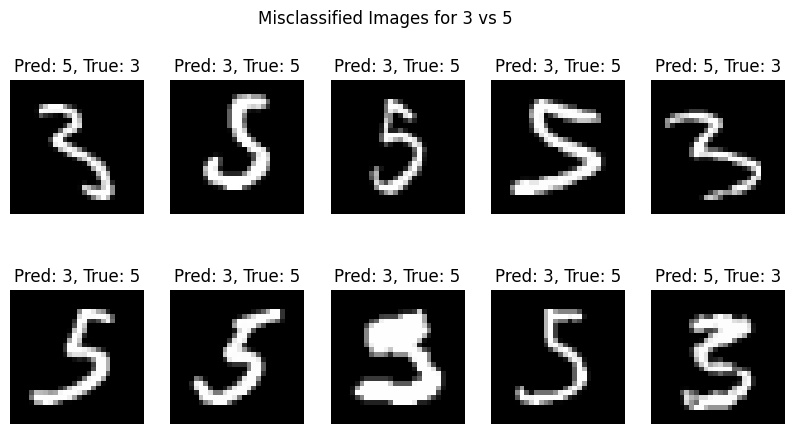

In [31]:
misclassified_idx35 = np.where(y35_pred != y35)[0]

print("Number of misclassified samples:", len(misclassified_idx35))
print("Feature size per sample:", X35.shape[1])

side35 = int(np.sqrt(X35.shape[1]))
if side35 * side35 == X35.shape[1] and len(misclassified_idx35) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx35[:10]):
        ax.imshow(X35[idx].reshape(side35, side35), cmap="gray")
        pred_label = 5 if y35_pred[idx] == 1 else 3
        true_label = 5 if y35[idx] == 1 else 3
        ax.set_title(f"Pred: {pred_label}, True: {true_label}")
        ax.axis("off")
    plt.suptitle("Misclassified Images for 3 vs 5")
    plt.show()
else:
    print("Misclassified images cannot be displayed because the feature count cannot be reshaped into a square image.")


## Task 3 Conclusion

The perceptron was trained to classify digits 3 and 5.
The final accuracy shows how well the model separated the two classes.

Because the provided dataset does not contain 784-pixel images, direct image visualization was not possible when the feature count was not a perfect square.
So the model was evaluated mainly using prediction accuracy and number of misclassified samples.
